## Importing IPP

In [1]:
import ipp

In [2]:
# model_Eval = ipp.pd.DataFrame()
ipp.warnings.filterwarnings("ignore")
ipp.initial_Check()

In [3]:
df = ipp.pd.read_csv('/Users/nikhilprao/Documents/Data/Boston.csv', index_col=0)
df.reset_index(drop=True)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0


## ask user for file 
### for now its commented 

In [4]:
# import tkinter as tk
# from tkinter import filedialog

# # Initialize tkinter window
# root = tk.Tk()
# root.withdraw()  # Hide the root window

# # Ask the user to upload any file
# file_path = filedialog.askopenfilename(title="Select a file")

# # Send the uploaded file to the function
# if file_path:
#     df = ipp.load_data(file_path)
#     print("Dataset loaded successfully!")
# else:
#     print("No file selected.")


## Pre processing unit will come here

In [5]:
df.isnull().sum()
# applying the method
nan_in_df = df.isnull().sum().any()
 
# Print the dataframe
print(type(nan_in_df))

df.info()

df.describe()

<class 'numpy.bool_'>
<class 'pandas.core.frame.DataFrame'>
Index: 506 entries, 1 to 506
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  lstat    506 non-null    float64
 12  medv     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 55.3 KB


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


### Ask User for predictive column

In [6]:
# Display column names to the user
print("Available predictor variables:")
for idx, col in enumerate(df.columns):
    print(f"{idx + 1}. {col}")

# Ask the user to choose a predictor variable
selected_index = int(input("Enter the index of the predictor variable you want to choose: ")) - 1

# Validate user input
if 0 <= selected_index < len(df.columns):
    pattern = df.columns[selected_index]
    print(f"Selected predictor variable: {pattern}")
else:
    print("Invalid index selected. Please choose a valid index.")


predictor_variable = df.filter(regex=f'^{pattern}').columns[0]

Available predictor variables:
1. crim
2. zn
3. indus
4. chas
5. nox
6. rm
7. age
8. dis
9. rad
10. tax
11. ptratio
12. lstat
13. medv
Selected predictor variable: medv


## rename the pred column if required

In [7]:
# # Rename the column if it contains the predictor_variable with a suffix (e.g., medv_power -> medv)
# def rename(df, predictor_variable):
#     return df.rename(columns={col: predictor_variable if predictor_variable in col else col for col in df.columns})

# df_skew = rename(df_skew, predictor_variable)

# # Print the modified DataFrame
# print(df_skew)

## Model starts here

In [8]:
ipp.interModel(df, predictor_variable, "raw")

## Pipeline for Outliers

In [9]:
df_outlier_cleaned = ipp.main_outliers(df, predictor_variable)

IQR method removes: 40 outliers
SD3 method removes: 0 outliers
Percentile method removes: 6 outliers
Method: iqr, Outliers removed: 40
Method: sd3, Outliers removed: 0
Method: percentile, Outliers removed: 6

Best method used: iqr
Number of outliers removed: 40


In [10]:
ipp.interModel(df_outlier_cleaned, predictor_variable, "outliers")
# ipp.Comp_plot_boxplots(df, df_outlier_cleaned, predictor_variable)

## Viz

In [11]:
# fig, axs = ipp.ipp.plt.subplots(ncols=7, nrows=2, figsize=(20, 10))
# index = 0
# axs = axs.flatten()
# for col, value in df_outlier_cleaned.items() :
#     ipp.ipp.sns.distplot(value, ax=axs[index])
#     index += 1
# ipp.ipp.plt. tight_layout (pad=0.5, w_pad=0.7, h_pad=5.0)

In [12]:
# #box plot to all features to show outliers
# fig, axs = ipp.ipp.plt.subplots(ncols=7, nrows=2, figsize=(20, 10))
# index = 0
# axs = axs.flatten()
# for col, value in df_outlier_cleaned.items():
#     ipp.ipp.sns.boxplot(y=col, data=df_outlier_cleaned, ax=axs[index])
#     index += 1
# ipp.ipp.plt.tight_layout (pad=0.5, w_pad=0.7, h_pad=5.0)

In [13]:
# ipp.plot_numerical_columns(df_outlier_cleaned)

In [14]:
# ipp.ipp.sns.pairplot(df_outlier_cleaned)

## Co relation matrix

<class 'pandas.core.frame.DataFrame'>


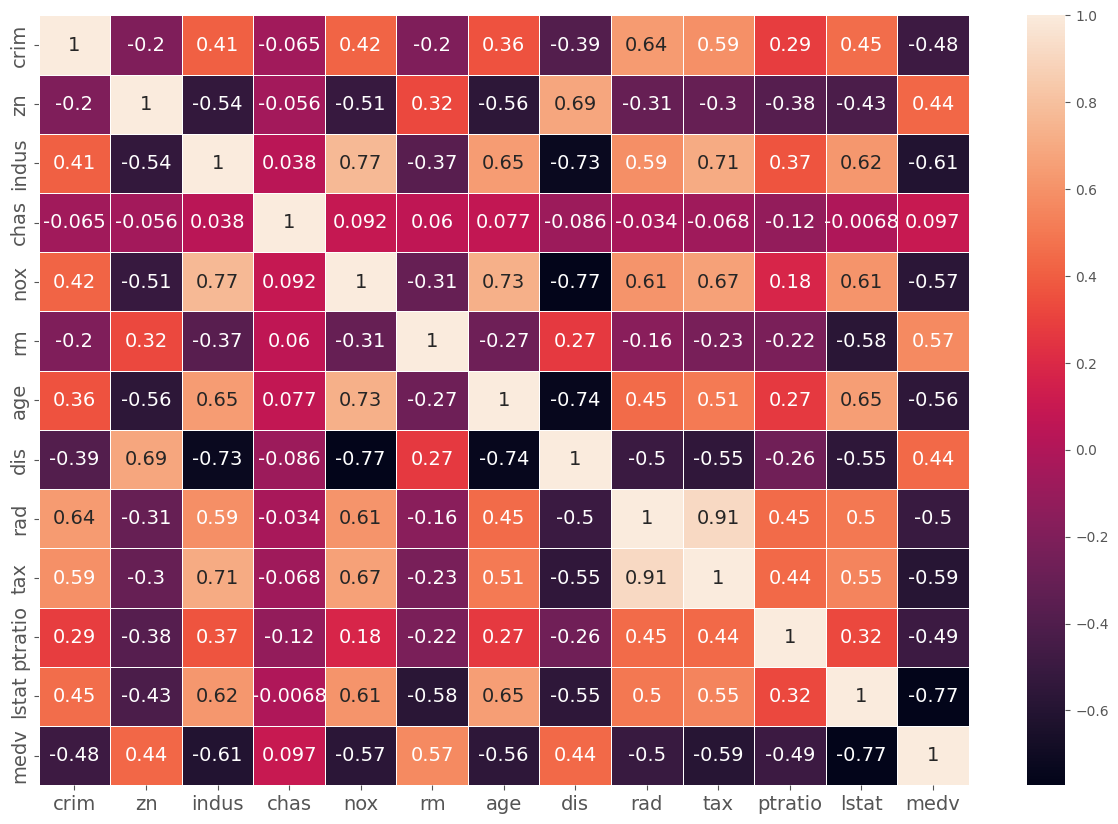

In [15]:
corr_mat=df_outlier_cleaned.corr()
print(type(corr_mat))
ipp.corrplot(corr_mat)

In [16]:
unique_counts = df.nunique()
print(unique_counts)
df_outlier_cleaned.info()

crim       504
zn          26
indus       76
chas         2
nox         81
rm         446
age        356
dis        412
rad          9
tax         66
ptratio     46
lstat      455
medv       229
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 466 entries, 1 to 506
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     466 non-null    float64
 1   zn       466 non-null    float64
 2   indus    466 non-null    float64
 3   chas     466 non-null    int64  
 4   nox      466 non-null    float64
 5   rm       466 non-null    float64
 6   age      466 non-null    float64
 7   dis      466 non-null    float64
 8   rad      466 non-null    int64  
 9   tax      466 non-null    int64  
 10  ptratio  466 non-null    float64
 11  lstat    466 non-null    float64
 12  medv     466 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.0 KB


## Adding the threshold from corr matrix for model

In [17]:
df_filtered, high_loss = ipp.remove_high_correlation_features(df_outlier_cleaned,predictor_variable)
print(high_loss)
# Output: {'High_loss': {'feature3': 0.91, 'feature4': 0.95}, 'Threshold': 0.9}
# print(df_filtered.head(2))
ipp.update_high_correlation_features(high_loss["High_loss"])

{'High_loss': {'rad': 0.9101}, 'Threshold': 0.9}


In [18]:
low_threshold_value = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55]
results = {}

for i in low_threshold_value:
    df_filtered, low_loss = ipp.remove_low_correlation_features(df_outlier_cleaned, i, predictor_variable)
    num_features = len(low_loss["Low_loss"])
    
    results[i] = {
        "df_filtered": df_filtered,  # Stores the dataframe
        "num_features": num_features  # Stores the number of low-correlation features removed
    }

    model_name = "LTH_"
    ipp.interModel(df_filtered, predictor_variable, model_name+str(i))
    ipp.update_low_correlation_features(i, low_loss["Low_loss"])
    # print(df_filtered.head(2))
    # print(" ----------------- ")

# Return the dictionary containing all results
# results


In [19]:
df_04 = results[0.4]["df_filtered"]
df_04.head(2)

,crim,zn,indus,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
1,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
2,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6


## Skew Handling

In [20]:
# Define skewness thresholds
high_skew_threshold = 1
moderate_skew_threshold = 0.5

# Calculate skewness for all columns
skew_values = df_04.skew()

# Categorize columns based on skewness values
highly_skewed = skew_values[abs(skew_values) > high_skew_threshold].index.tolist()
moderately_skewed = skew_values[(abs(skew_values) >= moderate_skew_threshold) & (abs(skew_values) <= high_skew_threshold)].index.tolist()
low_skew = skew_values[abs(skew_values) < moderate_skew_threshold].index.tolist()

# Print categorized columns
print("Highly Skewed:", highly_skewed)
print("Moderately Skewed:", moderately_skewed)
print("Low Skew:", low_skew)

Highly Skewed: ['crim', 'zn', 'dis']
Moderately Skewed: ['nox', 'age', 'rad', 'tax', 'ptratio', 'lstat']
Low Skew: ['indus', 'rm', 'medv']


In [21]:
type(highly_skewed)

list

In [22]:
df_outlier_cleaned.skew()

crim       5.268175
zn         2.293420
indus      0.271143
chas       3.714234
nox        0.734552
rm        -0.365107
age       -0.603338
dis        1.004178
rad        0.968681
tax        0.638410
ptratio   -0.867954
lstat      0.921894
medv       0.202563
dtype: float64

## Normality check of each data frame

In [23]:
normality_results = ipp.check_normality(df_04)
# print(normality_results)

## Skew Handling

In [24]:
# Main function to apply skew handling
def skew_handling(df, highly_skewed, moderately_skewed):
    df = ipp.handle_high_skew(df, highly_skewed)  # Handling high skew
    ipp.interModel(df, predictor_variable, "High_skew")
    df = ipp.handle_moderate_skew(df, moderately_skewed)  # Handling moderate skew
    ipp.interModel(df, predictor_variable, "Moderate_skew")
    
    print("\n Skew Handling Completed. Returning Transformed DataFrame.")
    return df

# Example Usage:
# df_selected_3 = skew_handling(df_selected_3, highly_skewed, moderately_skewed)



🔹 Transforming Highly Skewed Features...


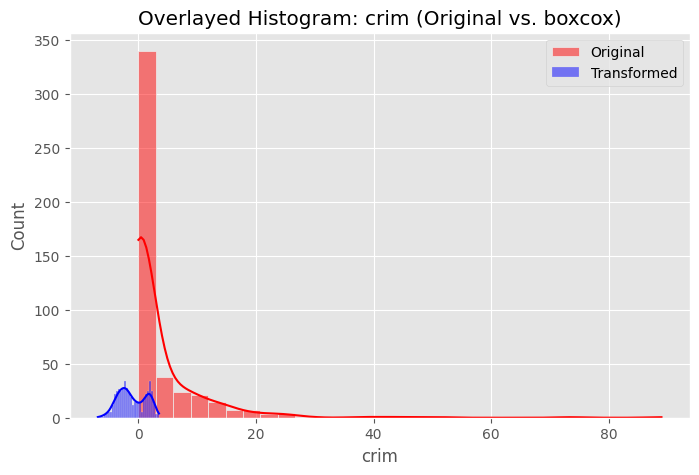

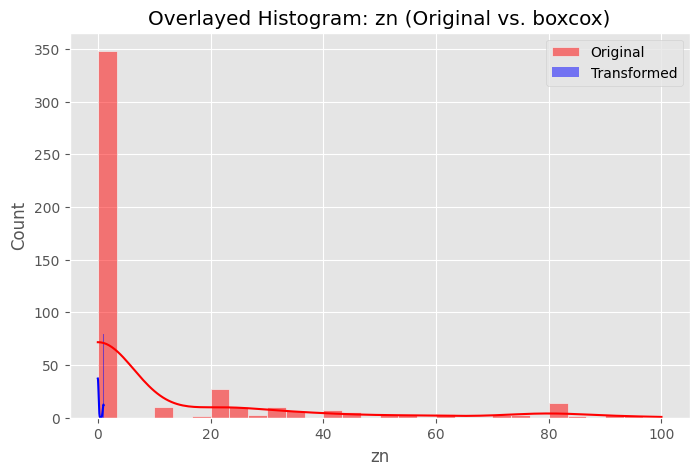

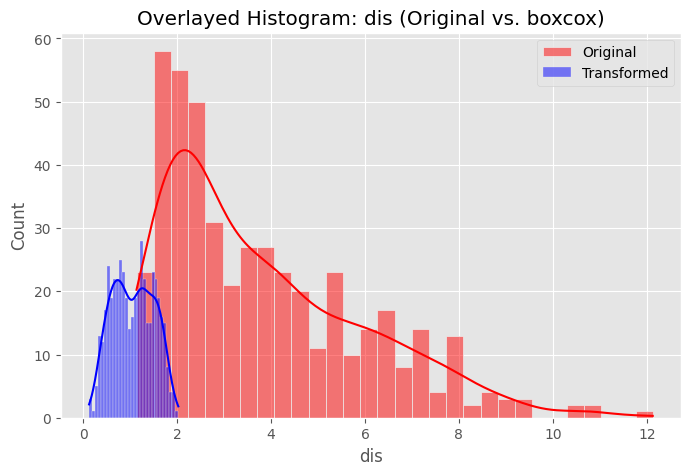


✅ Completed Transformations for Highly Skewed Features.

🔹 Applying Winsorization to Moderately Skewed Features...


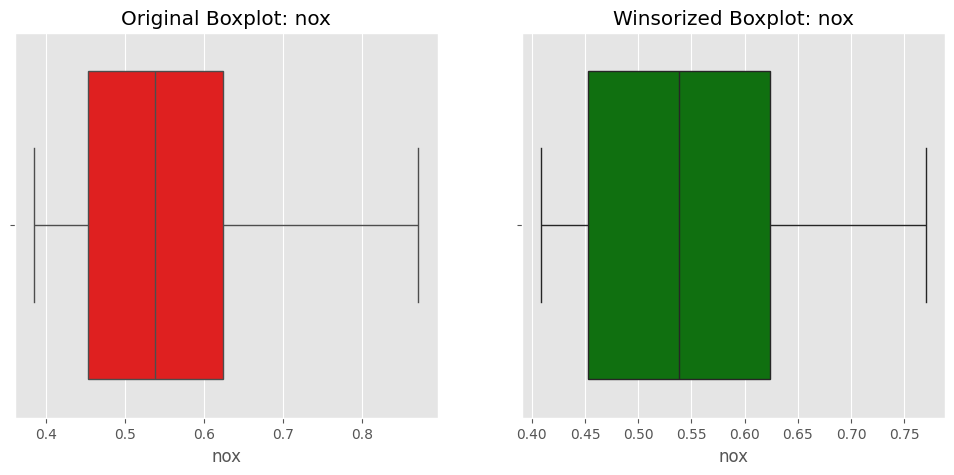

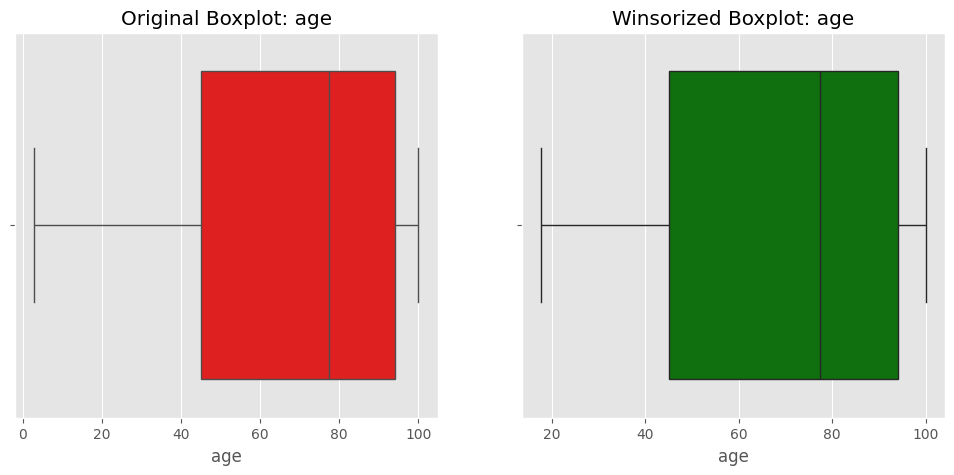

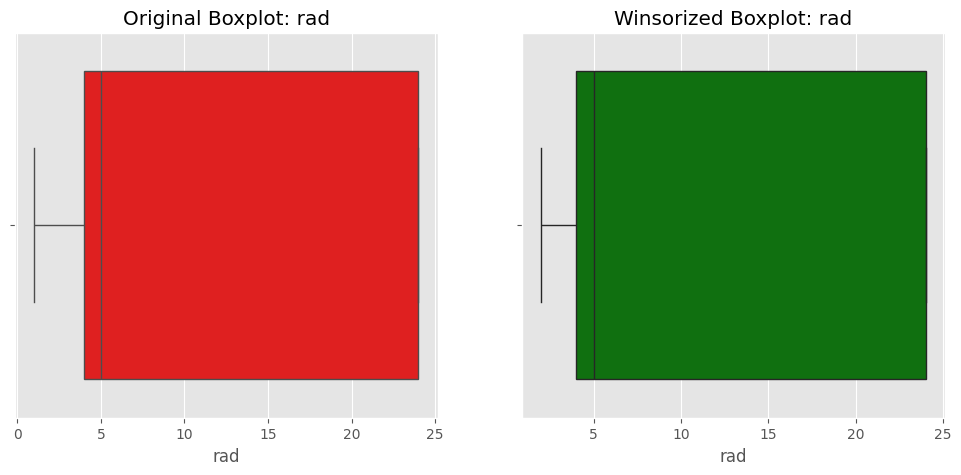

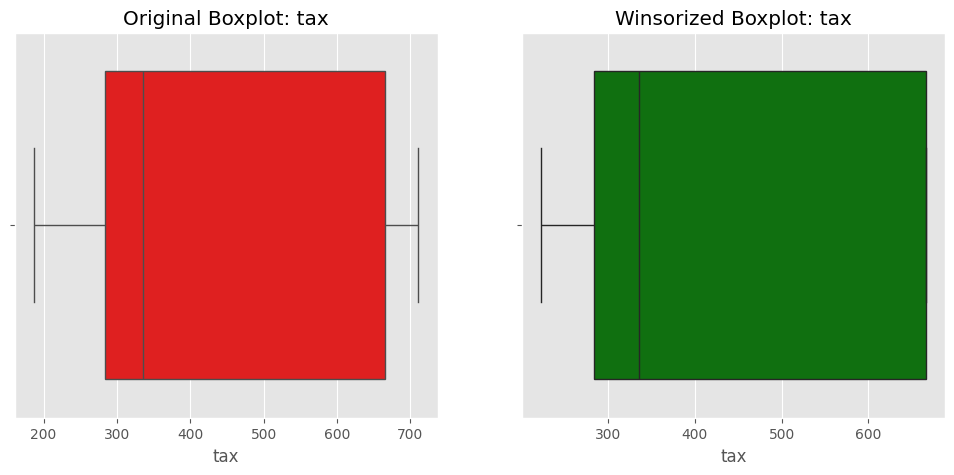

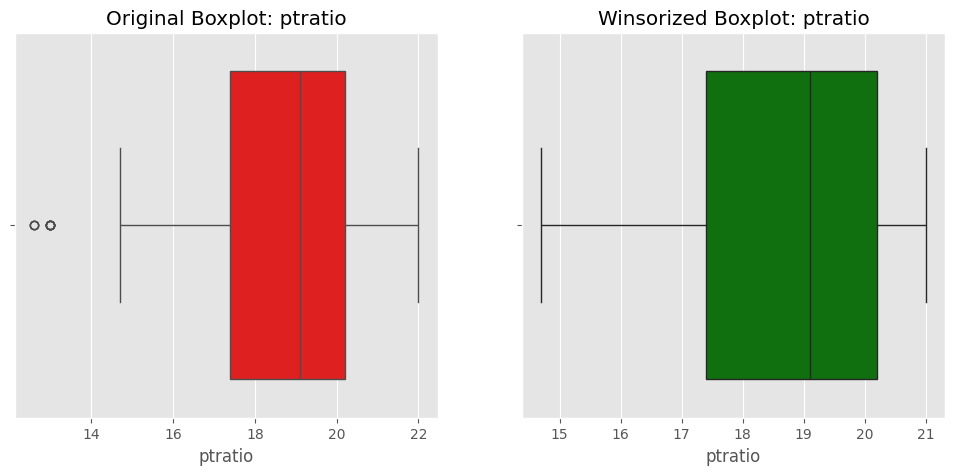

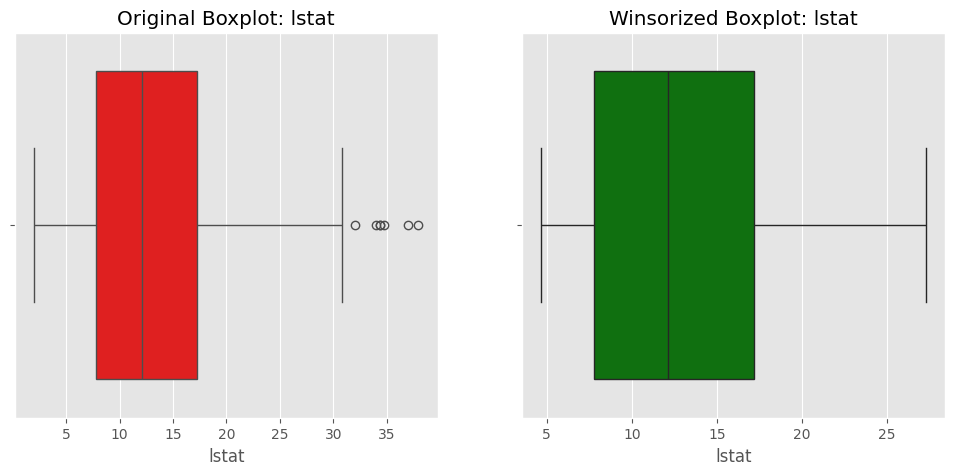


✅ Completed Winsorization for Moderately Skewed Features.

 Skew Handling Completed. Returning Transformed DataFrame.


In [25]:
df_skew = skew_handling(df_04, highly_skewed, moderately_skewed)

In [26]:
try:
    with open(ipp.json_file_path, "r") as file:
        status_data = ipp.json.load(file)
except FileNotFoundError:
    # If the file doesn't exist, initialize an empty structure
    status_data = {}

# Now you can safely modify the status_data object
status_data["pre_processing"]["Skew"]["Low"]["handling"] = False
status_data["pre_processing"]["Skew"]["Low"]["features"] = low_skew

# Write the updated status back to the file
with open(ipp.json_file_path, "w") as file:
    ipp.json.dump(status_data, file, indent=4)



### Cpmparing the columns in case the data frame changed or not

In [27]:
# # Define the predictor variable
# # predictor_variable = "medv"

# # Filter out the columns containing predictor_variable and predictor_variable_ in their names
# columns_to_compare = [col for col in df_04.columns if predictor_variable not in col]

# # Subset the DataFrames to include only the columns we want to compare
# df_selected_3_filtered = df_selected_3[columns_to_compare]
# df_trimmed_filtered = df_trimmed[columns_to_compare]

# # Compare the filtered DataFrames
# are_identical = df_selected_3_filtered.equals(df_trimmed_filtered)

# print("Are the DataFrames identical (excluding the predictor variable columns)?  ->  ", are_identical)


# Clean UP

In [29]:
clean = bool(int(input("Enter 1 for Yes, 0 for No: ")))  # Converts 1 to True and 0 to False
if clean:
    ipp.initial_Check()
else: print("  BYE  ")